# Polynomial Regression - Complete Implementation & Comparison

## Introduction

**Polynomial Regression** is a form of regression analysis where the relationship between the independent variable $x$ and dependent variable $y$ is modeled as an $n$-th degree polynomial. It is used when the data shows a **non-linear relationship**.

---

## Why Polynomial Regression?

| Scenario | Linear Regression | Polynomial Regression |
|----------|-------------------|----------------------|
| Linear Data | ✅ Works well | Overkill |
| Curved/Non-linear Data | ❌ Underfits | ✅ Captures patterns |
| Complex Patterns | ❌ Cannot model | ✅ Flexible |

---

## Mathematical Foundation

### General Form

For a polynomial of degree $m$:

$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + ... + \beta_m x^m + \epsilon$$

Or more compactly:

$$y = \sum_{i=0}^{m} \beta_i x^i + \epsilon$$

Where:
- $\beta_0, \beta_1, ..., \beta_m$ = polynomial coefficients
- $m$ = degree of the polynomial
- $\epsilon$ = error term

---

## Key Insight: Still Linear Regression!

Polynomial regression is actually **Linear Regression in disguise**. By creating new features:

$$x_1 = x, \quad x_2 = x^2, \quad x_3 = x^3, \quad ..., \quad x_m = x^m$$

The model becomes:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_m x_m$$

This is a **linear combination of features**, so we can use the same linear regression techniques!

---

## 📐 Matrix Representation

Let's derive the general formula.

**Assume:**
- $n$ = number of training examples
- $m$ = polynomial degree

### 🔹 Feature Transformation Matrix

We create a new feature matrix:

$$X = \begin{bmatrix} 
1 & x_1 & x_1^2 & x_1^3 & \cdots & x_1^m \\
1 & x_2 & x_2^2 & x_2^3 & \cdots & x_2^m \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_n & x_n^2 & x_n^3 & \cdots & x_n^m
\end{bmatrix}$$

**Dimension:**

$$X \in \mathbb{R}^{n \times (m+1)}$$

---

## 5️⃣ Model in Vector Form

$$\hat{y} = X\beta$$

Where:

$$\beta = \begin{bmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_m \end{bmatrix}$$

---

## 📝 Matrix Equation in Expanded Form

We rewrite the formula as a matrix equation:

$$\hat{y} = X\beta + E$$

**In expanded form:**

$$\begin{bmatrix} y_1 \\ y_2 \\ y_3 \\ \vdots \\ y_n \end{bmatrix} = \begin{bmatrix} 1 & x_1 & x_1^2 & x_1^3 & \cdots & x_1^m \\ 1 & x_2 & x_2^2 & x_2^3 & \cdots & x_2^m \\ 1 & x_3 & x_3^2 & x_3^3 & \cdots & x_3^m \\ \vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_n & x_n^2 & x_n^3 & \cdots & x_n^m \end{bmatrix} \begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \\ \beta_3 \\ \vdots \\ \beta_m \end{bmatrix} + \begin{bmatrix} \epsilon_1 \\ \epsilon_2 \\ \epsilon_3 \\ \vdots \\ \epsilon_n \end{bmatrix}$$

### Dimensions:

| Matrix | Dimension | Description |
|--------|-----------|-------------|
| $y$ | $n \times 1$ | Target vector |
| $X$ | $n \times (m+1)$ | Design matrix (polynomial features) |
| $\beta$ | $(m+1) \times 1$ | Coefficient vector |
| $E$ | $n \times 1$ | Error vector |

### Element-wise Expansion:

For each observation $i$:

$$y_i = \beta_0 \cdot 1 + \beta_1 \cdot x_i + \beta_2 \cdot x_i^2 + \beta_3 \cdot x_i^3 + ... + \beta_m \cdot x_i^m + \epsilon_i$$

Or equivalently:

$$y_i = \sum_{j=0}^{m} \beta_j x_i^j + \epsilon_i$$

---

## 6️⃣ Cost Function (Mean Squared Error)

$$J(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**In matrix form:**

$$J(\beta) = \frac{1}{2n} (y - X\beta)^T (y - X\beta)$$

**Expanded:**

$$J(\beta) = \frac{1}{2n} \left[ (y - X\beta)^T (y - X\beta) \right] = \frac{1}{2n} \left[ y^Ty - 2\beta^T X^T y + \beta^T X^T X \beta \right]$$

---

## 7️⃣ 🔥 Derivation of Normal Equation (Closed Form Solution)

We minimize the cost function:

$$J(\beta) = \frac{1}{2n} (y - X\beta)^T (y - X\beta)$$

### Step 1: Take derivative w.r.t β

$$\frac{\partial J}{\partial \beta} = -\frac{1}{n} X^T (y - X\beta)$$

### Step 2: Set derivative = 0

$$X^T (y - X\beta) = 0$$

### Step 3: Expand

$$X^T y - X^T X\beta = 0$$

$$X^T X\beta = X^T y$$

### Step 4: Solve for β

$$\boxed{\beta = (X^T X)^{-1} X^T y}$$

✅ **This is the Normal Equation for Polynomial Regression**

---

## 8️⃣ Gradient Descent Update Rule (Alternative)

Instead of matrix inverse, we can use gradient descent:

$$\beta := \beta - \alpha \frac{1}{n} X^T (X\beta - y)$$

Where:
- $\alpha$ = learning rate

---

## 9️⃣ Bias-Variance Tradeoff

| Degree | Behavior |
|--------|----------|
| Low degree | **Underfitting** (High Bias) |
| Moderate degree | Good fit |
| High degree | **Overfitting** (High Variance) |

Higher degree → more flexible → more risk of overfitting.

---

## 🔟 Example Polynomial Shapes

### Degree 2 (Quadratic):

$$y = \beta_0 + \beta_1 x + \beta_2 x^2$$

**Can model:**
- U-shape (parabola opening up)
- Inverted U-shape (parabola opening down)

### Degree 3 (Cubic):

$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3$$

**Can model:**
- S-shaped curves
- Curves with one inflection point

### Degree 4+:

**Can model:**
- Multiple peaks and valleys
- Complex oscillating patterns

---

## Vectorized Formulation Summary

| Component | Formula | Dimension |
|-----------|---------|-----------|
| Feature Matrix | $X = [1, x, x^2, ..., x^m]$ | $n \times (m+1)$ |
| Coefficient Vector | $\beta = [\beta_0, \beta_1, ..., \beta_m]^T$ | $(m+1) \times 1$ |
| Prediction | $\hat{y} = X\beta$ | $n \times 1$ |
| Normal Equation | $\beta = (X^T X)^{-1} X^T y$ | $(m+1) \times 1$ |
| Gradient | $\nabla J = \frac{1}{n} X^T (X\beta - y)$ | $(m+1) \times 1$ |

In [85]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

---

## Setup and Imports

| Library | Purpose |
|---------|---------|
| `numpy` | Numerical computations |
| `matplotlib` | Visualization |
| `sklearn.preprocessing.PolynomialFeatures` | Generate polynomial features |
| `sklearn.linear_model.LinearRegression` | Fit linear model |
| `sklearn.linear_model.SGDRegressor` | Gradient descent optimization |
| `sklearn.pipeline.Pipeline` | Chain preprocessing + model |
| `sklearn.preprocessing.StandardScaler` | Feature normalization |

In [86]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

---

## 1️⃣ Generating Synthetic Data

### True Relationship (Ground Truth)

We create data following a **quadratic polynomial**:

$$y = 0.8x^2 + 0.9x + 2 + \epsilon$$

Where:
- $0.8$ = coefficient for $x^2$ term
- $0.9$ = coefficient for $x$ term  
- $2$ = intercept/bias term
- $\epsilon \sim \mathcal{N}(0, 1)$ = Gaussian noise

### Data Generation Strategy
- 200 random samples
- $x \in [-3, 3]$ (uniform distribution)
- Added noise simulates real-world measurement errors

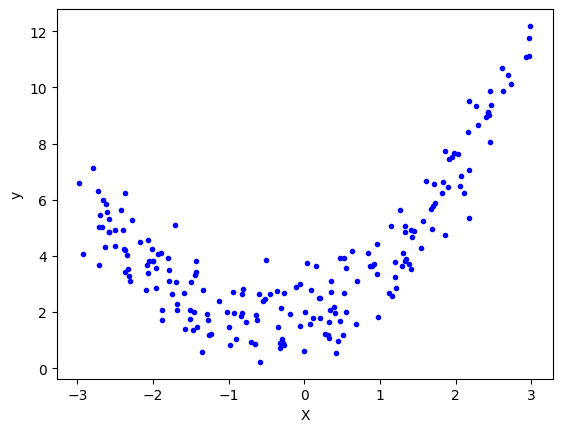

In [87]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [88]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

---

## 2️⃣ Baseline: Linear Regression (Underfitting Demo)

### Why Linear Regression Will Fail

The true relationship is **quadratic** ($y = ax^2 + bx + c$), but linear regression fits:

$$\hat{y} = w_1x + w_0$$

This is a **straight line** trying to fit a **parabola** → **Underfitting**

### Expected Result
- Poor R² score (much less than 1)
- The line will cut through the curve, missing the pattern

In [89]:
# Applying linear regression
lr = LinearRegression()

In [90]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [91]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.28875258636078416

### Linear Regression R² Score

The R² score shows how poorly linear regression fits our quadratic data. Since:
- **True model:** $y = 0.8x^2 + 0.9x + 2$
- **Linear model:** $y = w_1x + w_0$

The linear model cannot capture the $x^2$ term, resulting in a **low R² score**.

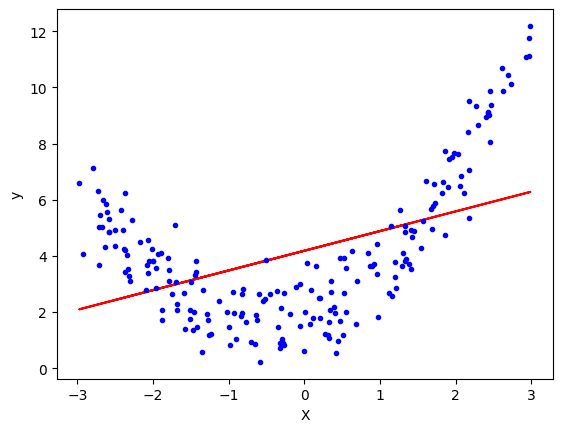

In [92]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [93]:
# Applying Polynomial Linear Regression
# degree 2
poly = PolynomialFeatures(degree=2,include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

---

## 3️⃣ Polynomial Feature Transformation

### The PolynomialFeatures Transformer

`PolynomialFeatures(degree=n)` transforms input features by creating polynomial combinations.

### For degree=2 (Quadratic):

Original feature: $[x]$

Transformed features: $[1, x, x^2]$

### Transformation Formula

For a single feature $x$ with `degree=2` and `include_bias=True`:

$$\phi(x) = [1, x, x^2]$$

### Example Transformation

| Original $x$ | Transformed $[1, x, x^2]$ |
|-------------|---------------------------|
| 2 | [1, 2, 4] |
| -1 | [1, -1, 1] |
| 3 | [1, 3, 9] |

### NumPy Implementation
```python
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X)  # Shape: (n_samples, 3)
```

In [94]:
print(X_train[0])
print(X_train_trans[0])

[-2.49800294]
[ 1.         -2.49800294  6.24001868]


In [95]:
# include_bias parameter

In [96]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Fitting Linear Regression on Polynomial Features

Now we fit a **Linear Regression** model on the **transformed polynomial features**.

**Model being fitted:**

$$\hat{y} = w_0 \cdot 1 + w_1 \cdot x + w_2 \cdot x^2$$

Which is equivalent to:

$$\hat{y} = w_0 + w_1 x + w_2 x^2$$

**Vectorized Form:**

$$\hat{Y} = X_{poly} \cdot W$$

Where:
- $X_{poly}$ = transformed feature matrix of shape `(n_samples, 3)`
- $W = [w_0, w_1, w_2]^T$ = coefficient vector

In [97]:
y_pred = lr.predict(X_test_trans)

In [98]:
r2_score(y_test,y_pred)

0.895130313246235

### R² Score - Evaluating Model Performance

**R² (Coefficient of Determination):**

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

| R² Value | Interpretation |
|----------|----------------|
| 1.0 | Perfect fit |
| 0.8 - 1.0 | Excellent |
| 0.6 - 0.8 | Good |
| < 0.6 | Poor |

For polynomial degree=2 (matching true relationship), we expect R² close to 1.0!

In [99]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.87904561 0.80917974]]
[1.89078424]


### Learned Coefficients Analysis

The coefficients learned by the model should be close to our ground truth:

| Parameter | True Value | Learned Value |
|-----------|------------|---------------|
| $w_2$ (for $x^2$) | 0.8 | ~0.8 |
| $w_1$ (for $x$) | 0.9 | ~0.9 |
| $w_0$ (intercept) | 2.0 | ~2.0 |

**Note:** `lr.coef_` returns $[w_0, w_1, w_2]$ when `include_bias=True` is used in PolynomialFeatures.

In [100]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

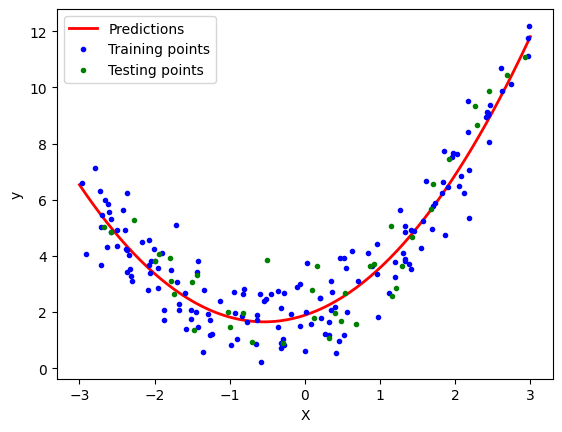

In [101]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [102]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

---

## 4️⃣ Exploring Different Polynomial Degrees (Bias-Variance Tradeoff)

### The Overfitting Problem

| Degree | Model Complexity | Risk |
|--------|-----------------|------|
| Low (1-2) | Simple | **Underfitting** (High Bias) |
| Medium (2-5) | Balanced | Good fit |
| High (10+) | Complex | **Overfitting** (High Variance) |

### Bias-Variance Tradeoff

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

- **High Bias (Underfitting):** Model is too simple, misses patterns
- **High Variance (Overfitting):** Model memorizes training data, fails on new data

### Pipeline Explanation

```python
Pipeline([
    ("poly_features", PolynomialFeatures(degree=n)),  # Transform features
    ("std_scaler", StandardScaler()),                  # Normalize (important for high degrees!)
    ("lin_reg", LinearRegression()),                   # Fit model
])
```

**Why StandardScaler?** For high-degree polynomials, feature values can become very large (e.g., $x^{10}$), causing numerical instability.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:1163: RuntimeWarning:

overflow encountered in square

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning:

overflow encountered in reduce

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning:

divide by zero encountered in matmul

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning:

overflow encountered in matmul

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning:

invalid value encountered in matmul



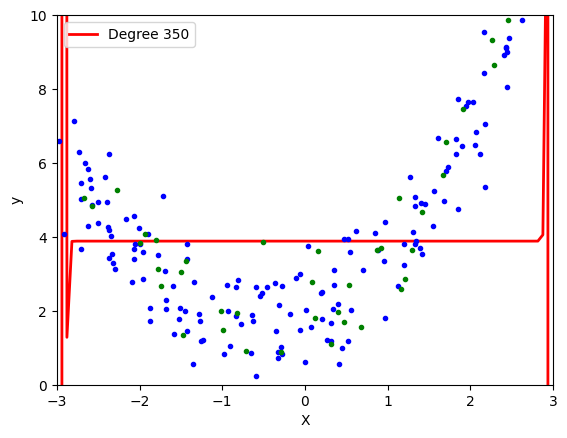

In [103]:
polynomial_regression(350)

### ⚠️ High Degree Polynomial - Overfitting Demo

Using `degree=350` is **extreme overfitting**!

**What happens:**
- Model has 351 parameters for ~200 data points
- Curve passes through (or very close to) every training point
- Creates wild oscillations between points
- **Terrible generalization** to new data

**Visual Signs of Overfitting:**
- Curve has excessive wiggles
- Perfect fit on training data
- Poor performance on test data

In [104]:
poly.powers_

array([[0],
       [1],
       [2]])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



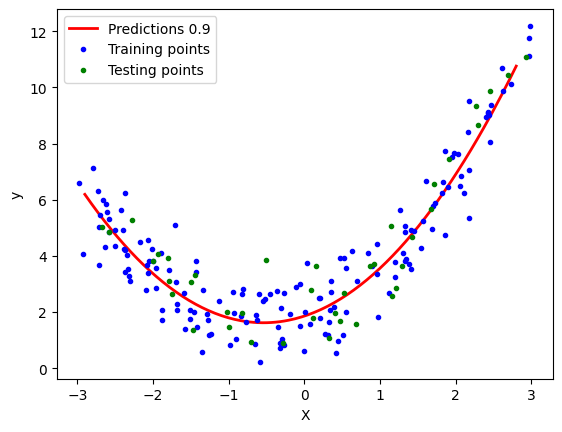

In [105]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

---

## 5️⃣ Polynomial Regression with Gradient Descent (SGDRegressor)

### Why Use Gradient Descent?

| Method | Approach | Best For |
|--------|----------|----------|
| **Normal Equation** | Direct solution $(X^TX)^{-1}X^Ty$ | Small datasets |
| **Gradient Descent** | Iterative optimization | Large datasets |

### SGDRegressor for Polynomial Regression

**Stochastic Gradient Descent (SGD)** can be used with polynomial features for efficient training on large datasets.

### Update Rule

$$W_{new} = W_{old} - \eta \cdot \nabla J(W)$$

Where the gradient for MSE loss:

$$\nabla J(W) = \frac{2}{m} X_{poly}^T (X_{poly} W - y)$$

### Key Parameters

| Parameter | Description |
|-----------|-------------|
| `max_iter` | Maximum number of passes over training data |
| `eta0` | Initial learning rate |
| `learning_rate` | Learning rate schedule ('constant', 'optimal', 'adaptive')

In [106]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

---

## 6️⃣ 3D Polynomial Regression (Multiple Features)

### Extending to Two Input Features

When we have two input features $x$ and $y$, polynomial regression becomes more powerful.

### True Relationship (Ground Truth)

$$z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2 + \epsilon$$

### Polynomial Features for 2 Variables

For `degree=2` with features $[x, y]$:

$$\phi(x, y) = [1, x, y, x^2, xy, y^2]$$

### General Formula for 2 Features, Degree $n$

Number of output features = $\binom{n + d}{d} = \frac{(n + d)!}{n! \cdot d!}$

Where:
- $n$ = number of input features (2 in this case)
- $d$ = polynomial degree

| Degree | Input Features | Output Features |
|--------|----------------|-----------------|
| 2 | 2 | 6 |
| 3 | 2 | 10 |
| 5 | 2 | 21 |

### Vectorized Representation

$$Z = X_{poly} \cdot W$$

Where $X_{poly}$ now contains all polynomial combinations up to the specified degree.

In [107]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [108]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)



### Baseline: Linear Regression on 2D Input (Plane Fitting)

First, we fit a **linear regression** (plane) to see how it performs:

$$z = w_1 x + w_2 y + w_0$$

This fits a **flat plane** to our curved surface → **Underfitting**

### 3D Visualization with Plotly

We use `meshgrid` to create a surface:
```python
x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input, y_input)
```

This creates a 10×10 grid for surface plotting.

In [109]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [110]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [111]:
poly = PolynomialFeatures(degree=30)
X_multi_trans = poly.fit_transform(X_multi)

### Polynomial Transformation for Multiple Features

For 2 input features with `degree=2`:

**Input:** $[x, y]$

**Output:** $[1, x, y, x^2, xy, y^2]$

### Powers Matrix Explanation

The `poly.powers_` attribute shows which powers are applied:

| Feature | $x^a$ | $y^b$ | Resulting Term |
|---------|-------|-------|----------------|
| 0 | 0 | 0 | $1$ (bias) |
| 1 | 1 | 0 | $x$ |
| 2 | 0 | 1 | $y$ |
| 3 | 2 | 0 | $x^2$ |
| 4 | 1 | 1 | $xy$ (interaction) |
| 5 | 0 | 2 | $y^2$ |

In [114]:
print("Input",poly.n_features_in_)
print("Ouput",poly.n_output_features_)
print("Powers\n",poly.powers_)

Input 2
Ouput 496
Powers
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 [ 2  0]
 [ 1  1]
 [ 0  2]
 [ 3  0]
 [ 2  1]
 [ 1  2]
 [ 0  3]
 [ 4  0]
 [ 3  1]
 [ 2  2]
 [ 1  3]
 [ 0  4]
 [ 5  0]
 [ 4  1]
 [ 3  2]
 [ 2  3]
 [ 1  4]
 [ 0  5]
 [ 6  0]
 [ 5  1]
 [ 4  2]
 [ 3  3]
 [ 2  4]
 [ 1  5]
 [ 0  6]
 [ 7  0]
 [ 6  1]
 [ 5  2]
 [ 4  3]
 [ 3  4]
 [ 2  5]
 [ 1  6]
 [ 0  7]
 [ 8  0]
 [ 7  1]
 [ 6  2]
 [ 5  3]
 [ 4  4]
 [ 3  5]
 [ 2  6]
 [ 1  7]
 [ 0  8]
 [ 9  0]
 [ 8  1]
 [ 7  2]
 [ 6  3]
 [ 5  4]
 [ 4  5]
 [ 3  6]
 [ 2  7]
 [ 1  8]
 [ 0  9]
 [10  0]
 [ 9  1]
 [ 8  2]
 [ 7  3]
 [ 6  4]
 [ 5  5]
 [ 4  6]
 [ 3  7]
 [ 2  8]
 [ 1  9]
 [ 0 10]
 [11  0]
 [10  1]
 [ 9  2]
 [ 8  3]
 [ 7  4]
 [ 6  5]
 [ 5  6]
 [ 4  7]
 [ 3  8]
 [ 2  9]
 [ 1 10]
 [ 0 11]
 [12  0]
 [11  1]
 [10  2]
 [ 9  3]
 [ 8  4]
 [ 7  5]
 [ 6  6]
 [ 5  7]
 [ 4  8]
 [ 3  9]
 [ 2 10]
 [ 1 11]
 [ 0 12]
 [13  0]
 [12  1]
 [11  2]
 [10  3]
 [ 9  4]
 [ 8  5]
 [ 7  6]
 [ 6  7]
 [ 5  8]
 [ 4  9]
 [ 3 10]
 [ 2 11]
 [ 1 12]
 [ 0 13]
 [14  0]
 [13  1]
 [12  2]
 [

In [115]:
X_multi_trans.shape

(100, 496)

In [116]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Fitting Polynomial Regression on 3D Data

Now we fit linear regression on the **polynomial transformed features**:

$$z = \sum_{i+j \leq d} w_{ij} \cdot x^i \cdot y^j$$

For degree=2:

$$z = w_0 + w_1 x + w_2 y + w_3 x^2 + w_4 xy + w_5 y^2$$

This allows the model to fit the **curved paraboloid surface** accurately!

In [117]:
X_test_multi = poly.transform(final)

In [118]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning:

divide by zero encountered in matmul

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning:

overflow encountered in matmul

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning:

invalid value encountered in matmul



In [119]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()

### 3D Surface Visualization

The polynomial regression surface should fit the data points much better than the flat plane from linear regression.

**Visualization Components:**
- **Scatter Points:** Original data points in 3D space
- **Surface:** The learned polynomial surface

The curved surface captures the quadratic relationship in the data.

---

## 📊 Summary & Conclusion

### What We Covered

| Topic | Key Concept |
|-------|-------------|
| **Polynomial Features** | Transform $x$ → $[1, x, x^2, ..., x^n]$ |
| **Linear Regression** | Used on transformed features (still linear in parameters!) |
| **Underfitting** | Low-degree model misses patterns |
| **Overfitting** | High-degree model memorizes noise |
| **Gradient Descent** | Alternative to Normal Equation for large data |
| **3D Regression** | Multiple features with polynomial combinations |

### Key Formulas

| Formula | Description |
|---------|-------------|
| $y = \sum_{i=0}^{n} w_i x^i$ | Polynomial model |
| $\hat{y} = X_{poly} \cdot W$ | Vectorized prediction |
| $W = (X^TX)^{-1}X^Ty$ | Normal equation solution |
| $W = W - \eta \nabla J$ | Gradient descent update |

### Best Practices

1. **Start with low degree** and increase if needed
2. **Use validation set** to detect overfitting
3. **Apply StandardScaler** for high-degree polynomials
4. **Consider regularization** (Ridge, Lasso) to prevent overfitting
5. **Use cross-validation** to find optimal degree

### When to Use Polynomial Regression

| ✅ Good Use Cases | ❌ Avoid When |
|------------------|--------------|
| Clear non-linear patterns | Linear relationship exists |
| Small to medium datasets | Very high dimensional data |
| Known polynomial structure | Need interpretable model |
| Curve fitting problems | Sparse data |

---

*This notebook demonstrates polynomial regression from basic concepts to 3D implementations, comparing different approaches and visualizing results.*